In [3]:
import fmatoolbox as fma
from math import *
import matplotlib.pyplot as plt
import numpy as np
import regions as rg
from scipy import signal
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

from scipy.spatial.distance import hamming, pdist, squareform
from scipy.cluster.hierarchy import linkage, fcluster
from sklearn.manifold import TSNE

%load_ext autoreload
%autoreload 2

In [4]:
session = '/mnt/hubel-data-131/perceval/Rat003_20231219/Rat003_20231219.xml'
R = rg.data.Regions(session,states=['sws','rem'],events=['ripples'])

Patterns

In [5]:
fr = R.unitFiringRate(regs=["nr"])

In [38]:
fr[:1]

array([[2.5e-02, 0.0e+00, 0.0e+00, 0.0e+00, 0.0e+00, 0.0e+00, 0.0e+00,
        0.0e+00, 0.0e+00, 0.0e+00, 0.0e+00, 0.0e+00, 0.0e+00, 0.0e+00,
        0.0e+00, 0.0e+00, 0.0e+00, 0.0e+00, 2.0e+01, 0.0e+00, 0.0e+00,
        2.0e+01, 0.0e+00, 0.0e+00, 2.0e+01, 0.0e+00, 0.0e+00, 2.0e+01,
        0.0e+00, 0.0e+00, 2.0e+01, 0.0e+00, 0.0e+00, 0.0e+00, 0.0e+00,
        0.0e+00, 0.0e+00, 0.0e+00, 2.0e+01, 4.0e+01, 0.0e+00, 2.0e+01,
        0.0e+00, 0.0e+00, 0.0e+00, 0.0e+00, 0.0e+00, 0.0e+00]])

In [33]:
fr = np.array([[0,0,1,0,0],[1,0,0,1,0],[2,0,1,1,0],[3,0,1,0,0],[4,0,0,0,0],[5,0,0,0,0],[6,0,0,0,1],[7,0,0,1,0],[8,0,1,0,0],[9,0,0,0,0]])

In [ ]:
patterns = [] 
nn = len(fr[0])
nt = len(fr)

# somme de l'activité sur tous les neurones à chaque timestep
activity = fr[:, 1:].sum(axis=1)  # shape (nt,), on ignore la colonne temps

# booléen : actif ou non à chaque timestep
active = activity > 0

# transitions
starts = np.where(~active[:-1] & active[1:])[0] + 1   # 0 -> actif
stops  = np.where(active[:-1] & ~active[1:])[0]        # actif -> 0

# cas où la première frame est active
if active[0]:
    starts = np.concatenate([[0], starts])

# cas où la dernière frame est active
if active[-1]:
    stops = np.concatenate([stops, [nt-1]])

intervals = np.column_stack([starts, stops])
intervals = intervals[intervals[:,1] - intervals[:,0] > 4] 

In [7]:
patterns = [(fr[start:stop+1, 1:].sum(axis=0)>0).astype(int) for start, stop in intervals]

In [12]:
print(patterns[:4])
print(len(patterns))
print(len(patterns[0]))

# dédupliquer les patterns
patterns_array = np.array(patterns)
unique_patterns, counts = np.unique(patterns_array, axis=0, return_counts=True)

print(f"Patterns totaux : {len(patterns)}")
print(f"Patterns uniques : {len(unique_patterns)}")

# utiliser unique_patterns pour le clustering
# et counts pour pondérer si besoin

patterns = unique_patterns

[array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1]), array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1]), array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1]), array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1])]
4191
47
Patterns totaux : 4191
Patterns uniques : 3822


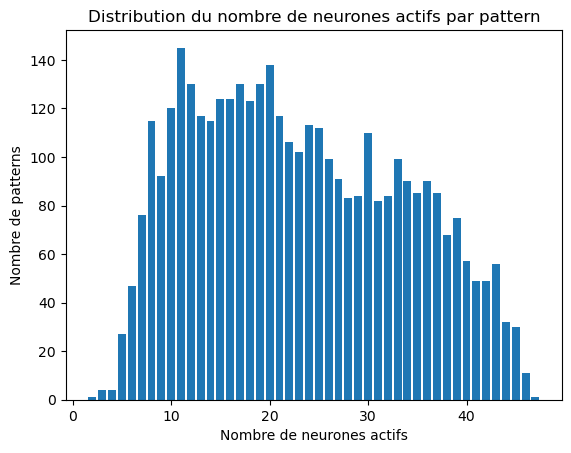

In [22]:
dp = {}
for i in range(len(patterns)):
    n = np.sum(patterns[i])
    if n not in dp:
        dp[n] = 0
    dp[n]+=1
l1,l2=[],[]
for i in dp:
    l1.append(i)
    l2.append(dp[i])

plt.bar(l1,l2)
plt.xlabel('Nombre de neurones actifs')
plt.ylabel('Nombre de patterns')
plt.title('Distribution du nombre de neurones actifs par pattern')
plt.show()

Matrice des patterns

[[0 0 0 ... 1 1 1]
 [0 0 0 ... 1 1 1]
 [0 0 0 ... 1 1 1]
 ...
 [0 0 0 ... 1 1 1]
 [0 0 0 ... 1 1 1]
 [0 0 0 ... 1 1 1]]


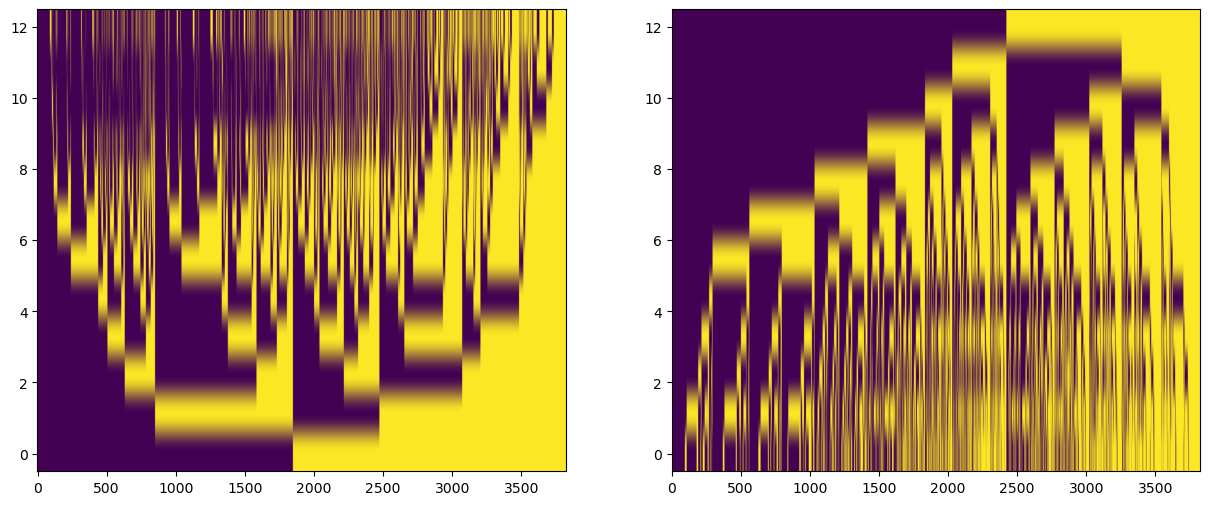

In [55]:
M = np.transpose(patterns)

fig, axs = plt.subplots(1,2, figsize=(15, 6))
ax1,ax2 = axs.flatten()

fma.plotting.plotColorMap(M, ax=ax1)

indices = np.lexsort(M)

M=M[:, indices]

print(M)

fma.plotting.plotColorMap(M, ax=ax2)


In [60]:
patterns = [(fr[start:stop+1, 1:].sum(axis=0)>0).astype(int) for start, stop in intervals]
patterns_array = np.array(patterns)
unique_patterns, counts = np.unique(patterns_array, axis=0, return_counts=True)
patterns = unique_patterns
p1 = patterns[:,:12]
p2 = patterns[:,13:]
#patterns=p1

Clustering

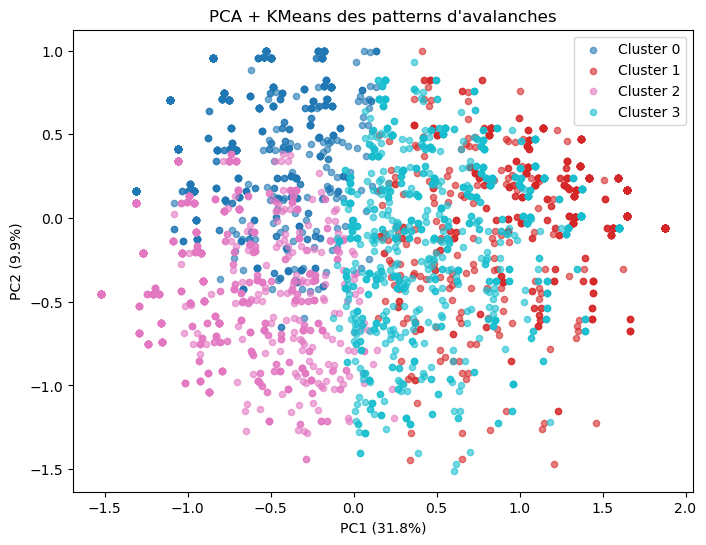

In [56]:

# 1. construire la matrice de patterns
X = np.array(patterns)  # shape (n_avalanches, n_neurons)

# 2. normalisation
scaler = StandardScaler()
#X_scaled = scaler.fit_transform(X)
X_scaled = X

# 3. clustering
n_clusters = 4  # à ajuster
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
labels = kmeans.fit_predict(X_scaled)

# 4. réduction de dimension
pca = PCA(n_components=2)
X_2d = pca.fit_transform(X_scaled)

# 5. plot
fig, ax = plt.subplots(figsize=(8, 6))
colors = plt.cm.tab10(np.linspace(0, 1, n_clusters))
for k in range(n_clusters):
    mask = labels == k
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1], 
               color=colors[k], label=f'Cluster {k}', alpha=0.6, s=20)
ax.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)')
ax.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)')
ax.set_title('PCA + KMeans des patterns d\'avalanches')
ax.legend()
plt.show()

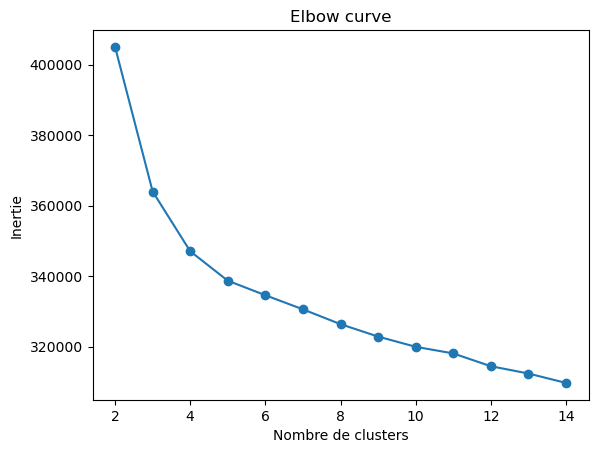

In [17]:
inertias = []
k_range = range(2, 15)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.plot(k_range, inertias, 'o-')
plt.xlabel('Nombre de clusters')
plt.ylabel('Inertie')
plt.title('Elbow curve')
plt.show()

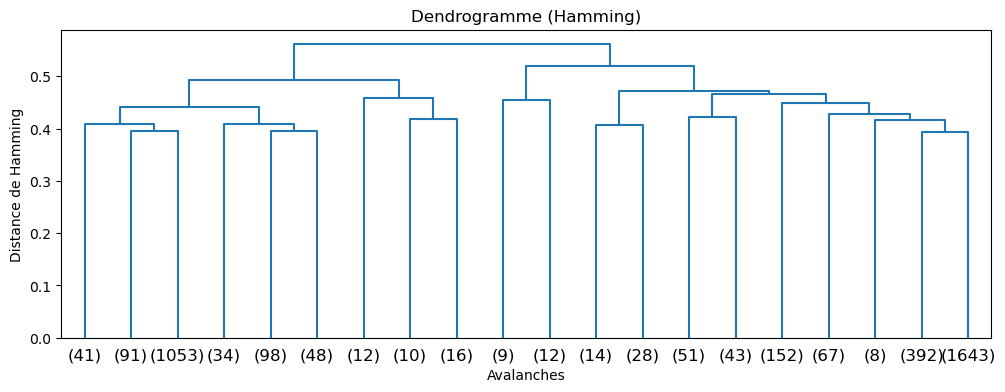

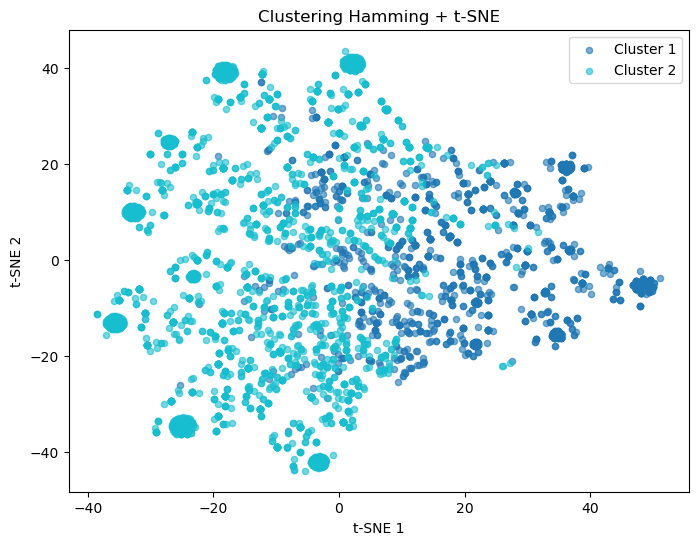

In [57]:
X = np.array(patterns)  # shape (n_avalanches, n_neurons)

# --- 1. Matrice de distances de Hamming ---
# pdist calcule toutes les paires de distances
hamming_distances = pdist(X, metric='hamming')
hamming_matrix = squareform(hamming_distances)  # shape (n_avalanches, n_avalanches)

# --- 2. Clustering hiérarchique sur Hamming ---
# 'ward' minimise la variance intra-cluster à chaque fusion
# autres options : 'average', 'complete', 'single'
linkage_matrix = linkage(hamming_distances, method='average')
n_clusters = 2  # à ajuster avec le dendrogramme
labels = fcluster(linkage_matrix, n_clusters, criterion='maxclust')

# optionnel : visualiser le dendrogramme pour choisir n_clusters
from scipy.cluster.hierarchy import dendrogram
fig_dend, ax_dend = plt.subplots(figsize=(12, 4))
dendrogram(linkage_matrix, ax=ax_dend, truncate_mode='lastp', p=20)
ax_dend.set_title('Dendrogramme (Hamming)')
ax_dend.set_xlabel('Avalanches')
ax_dend.set_ylabel('Distance de Hamming')
plt.show()

# --- 3. Réduction de dimension t-SNE ---
tsne = TSNE(
    n_components=2,
    metric='hamming',      # t-SNE utilise directement Hamming
    perplexity=min(50, len(X)//4),  # règle empirique : ~n_samples/4
    random_state=42,
    max_iter=1000
)
X_2d = tsne.fit_transform(X)

# --- 4. Plot ---
fig, ax = plt.subplots(figsize=(8, 6))
colors = plt.cm.tab10(np.linspace(0, 1, n_clusters))
for k in range(1, n_clusters + 1):  # fcluster commence à 1
    mask = labels == k
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               color=colors[k-1], label=f'Cluster {k}',
               alpha=0.6, s=20)
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.set_title('Clustering Hamming + t-SNE')
ax.legend()
plt.show()

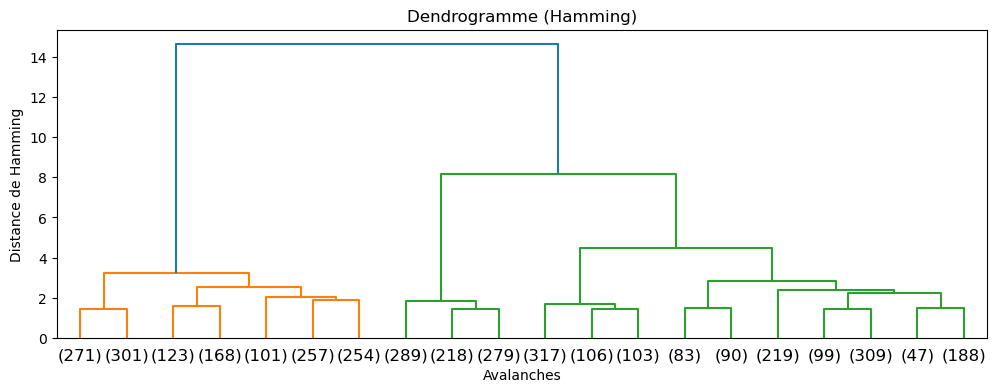

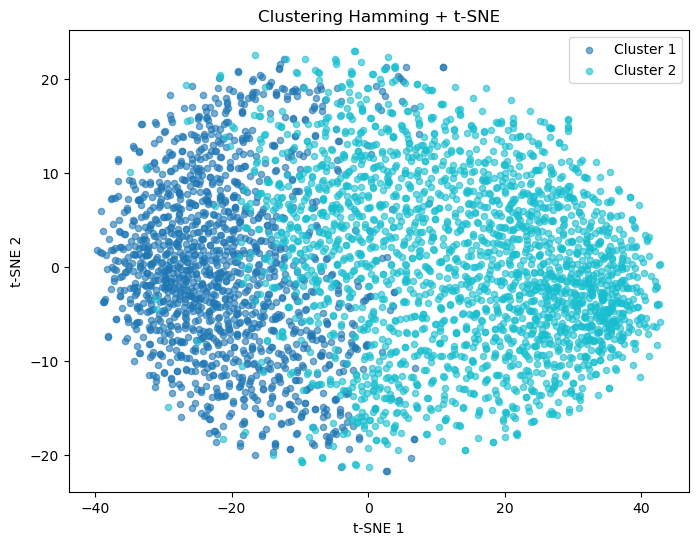

In [61]:
X = np.array(patterns)  # shape (n_avalanches, n_neurons)

# --- 1. Matrice de distances de Hamming ---
# pdist calcule toutes les paires de distances
hamming_distances = pdist(X, metric='hamming')
hamming_matrix = squareform(hamming_distances)  # shape (n_avalanches, n_avalanches)

# --- 2. Clustering hiérarchique sur Hamming ---
# 'ward' minimise la variance intra-cluster à chaque fusion
# autres options : 'average', 'complete', 'single'
linkage_matrix = linkage(hamming_distances, method='ward')
n_clusters = 2  # à ajuster avec le dendrogramme
labels = fcluster(linkage_matrix, n_clusters, criterion='maxclust')

# optionnel : visualiser le dendrogramme pour choisir n_clusters
from scipy.cluster.hierarchy import dendrogram
fig_dend, ax_dend = plt.subplots(figsize=(12, 4))
dendrogram(linkage_matrix, ax=ax_dend, truncate_mode='lastp', p=20)
ax_dend.set_title('Dendrogramme (Hamming)')
ax_dend.set_xlabel('Avalanches')
ax_dend.set_ylabel('Distance de Hamming')
plt.show()

# --- 3. Réduction de dimension t-SNE ---
tsne = TSNE(
    n_components=2,
    metric='hamming',      # t-SNE utilise directement Hamming
    perplexity=min(50, len(X)//4),  # règle empirique : ~n_samples/4
    random_state=42,
    max_iter=1000
)
X_2d = tsne.fit_transform(X)

# --- 4. Plot ---
fig, ax = plt.subplots(figsize=(8, 6))
colors = plt.cm.tab10(np.linspace(0, 1, n_clusters))
for k in range(1, n_clusters + 1):  # fcluster commence à 1
    mask = labels == k
    ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
               color=colors[k-1], label=f'Cluster {k}',
               alpha=0.6, s=20)
ax.set_xlabel('t-SNE 1')
ax.set_ylabel('t-SNE 2')
ax.set_title('Clustering Hamming + t-SNE')
ax.legend()
plt.show()

Réduction de dimension par t-SNE avant clustering : pas très pertinent :

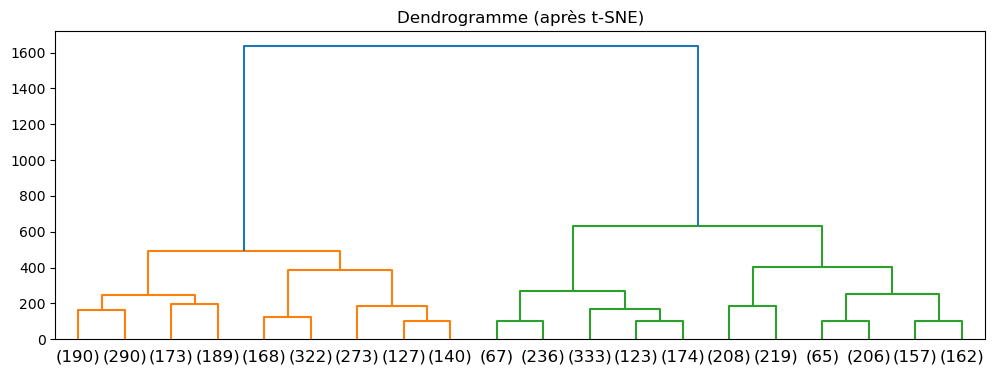

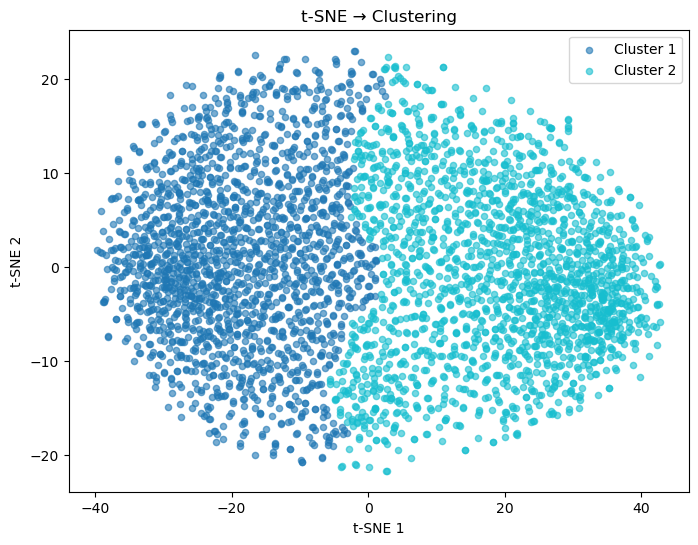

In [68]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.manifold import TSNE
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram

X = np.array(patterns)  # (n_avalanches, n_neurons)

# --- 1. Réduction de dimension ---
tsne = TSNE(
    n_components=2,
    metric='hamming',
    perplexity=min(50, len(X)//4),
    random_state=42,
    max_iter=1000
)

X_2d = tsne.fit_transform(X)

# --- 2. Distances dans l'espace réduit ---
distances = pdist(X_2d, metric='euclidean')
distance_matrix = squareform(distances)

# --- 3. Clustering hiérarchique ---
linkage_matrix = linkage(distances, method='ward')

n_clusters = 2
labels = fcluster(linkage_matrix, n_clusters, criterion='maxclust')

# --- 4. Dendrogramme ---
fig_dend, ax_dend = plt.subplots(figsize=(12,4))
dendrogram(linkage_matrix, ax=ax_dend, truncate_mode='lastp', p=20)
ax_dend.set_title('Dendrogramme (après t-SNE)')
plt.show()

# --- 5. Plot ---
fig, ax = plt.subplots(figsize=(8,6))

colors = plt.cm.tab10(np.linspace(0,1,n_clusters))

for k in range(1, n_clusters+1):
    mask = labels == k
    ax.scatter(
        X_2d[mask,0],
        X_2d[mask,1],
        color=colors[k-1],
        label=f'Cluster {k}',
        alpha=0.6,
        s=20
    )

ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
ax.set_title("t-SNE → Clustering")
ax.legend()

plt.show()

Tentative d'exploration des clusters

In [63]:
clust1 = patterns[labels == 1] 
clust2 = patterns[labels == 2]
len(clust1), len(clust2)

(1475, 2347)

In [65]:
nt = 25

counts1 = clust1.sum(axis=1)       # nombre de 1 par pattern
mean1   = counts1.mean()
std1    = counts1.std()
sup1=counts1[counts1>nt].sum()
p1 = sup1/len(counts1)

counts2 = clust2.sum(axis=1)       # nombre de 1 par pattern
mean2   = counts2.mean()
std2    = counts2.std()
sup2=counts2[counts2>nt].sum()
p2=sup2/len(counts2)

print(counts1)
print(counts2)

print(mean1, std1, mean2, std2)
print(sup1,p1,sup2,p2)

[ 7  6  6 ... 20 21 23]
[15 10 12 ... 46 46 47]
13.048135593220339 4.66487650374303 29.269279931827864 8.117002703328847
105 0.0711864406779661 51478 21.933532168726032
